# Kerswell horizontal Coulomb dam break — AVAC

This notebook tests Coulomb spreading and natural arrest against Kerswell's analytical solution. It evaluates both moving boundaries and depth profiles.


## Reproducible environment

The first code cell installs the repository's validation package and Python dependencies into the active kernel. A clean checkout also needs GNU Make and gfortran to compile the selected solver on first use.


In [1]:
from pathlib import Path
SEARCH_ROOT = Path.cwd().resolve()
REPOSITORY = next(candidate for candidate in (SEARCH_ROOT, *SEARCH_ROOT.parents) if (candidate / 'validation' / 'pyproject.toml').is_file())
%pip install -q -e {REPOSITORY / 'validation'}


Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
from avac4qgis_validation import validation_case
case = validation_case('AVAC', 'Kerswell_Coulomb')
CORES = max(1, os.cpu_count() or 1)
case.path


PosixPath('/Users/cmgotelli/Desktop/AVAC-QGIS/validation/AVAC/Kerswell_Coulomb')

## Physical and numerical definition

A one-meter-deep column spreads on a horizontal bed with basal Coulomb coefficient $\mu=0.1$. The state is uniform across a five-cell wall-bounded strip. There is no Voellmy turbulent term and no fitted stopping threshold; arrest must follow from the Coulomb/static-yield implementation. Three AMR levels refine narrow corridors around the independently known boundary paths from a 40 mm base mesh to a 2.5 mm finest mesh while leaving distant regions coarse.


In [3]:
BASE_DX_M = 0.04
AMR_LEVELS = 3
AMR_RATIO = 4
SPEED_TOLERANCE_M_S = 0.02
T_FINAL_S = 10.0
OUTPUT_FRAMES = 40
RUN_NAME = os.environ.get('AVAC_VALIDATION_RUN_NAME', 'publication_amr')
case.run('run_avac_validation.py', '--dx', BASE_DX_M, '--t-final', T_FINAL_S, '--nout', OUTPUT_FRAMES, '--cores', CORES, '--case-name', RUN_NAME, '--amr-levels', AMR_LEVELS, '--amr-ratio', AMR_RATIO, '--speed-tolerance', SPEED_TOLERANCE_M_S, '--max1d', 1000)


Running: /Users/cmgotelli/anaconda3/bin/python /Users/cmgotelli/Desktop/AVAC-QGIS/validation/AVAC/Kerswell_Coulomb/run_avac_validation.py --dx 0.04 --t-final 10.0 --nout 40 --cores 8 --case-name publication_amr --amr-levels 3 --amr-ratio 4 --speed-tolerance 0.02 --max1d 1000
* computational domain x = [-10.00, 30.00] m, nx = 1000
* computational domain y = [0.00, 0.20] m, ny = 5
*** WARNING: Selective output_aux_components not implemented
***          Will output all components of aux
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0/geoclaw/src/python/geoclaw/data.py:199: UserWarning: 
  *** WARNING: topofile specs changed in v5.8.0 -- Flag level info now ignored
  warnings.warn(w, UserWarning)
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0/geoclaw/src/python/geoclaw/data.py:142: UserWarning: 
  *** WARNING: deep_depth parameter ignored as of v5.8.0
  warnings.warn(w, UserWarning)
/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/clawpack-v5.14.0/geoclaw/src/pyth

## Quantitative diagnostics

Front/rear errors, arrested-state measures, mass history, and solver identity are written by the same run.


In [4]:
summary = case.json(f'{RUN_NAME}/results/summary.json')
summary


{'solver': '/Users/cmgotelli/Desktop/AVAC-QGIS/avac-main/src/AVAC/xgeoclaw',
 'solver_sha256': '6e85bee646c3d4730693b70323c7195ca84dc1b6a075d9ea1b803624838310f9',
 'diagnostic_dx_m': 0.0024999999999995026,
 'width_base_cells': 5,
 'amr_levels': 3,
 'refinement_ratios': [4, 4],
 'transverse_refinement_ratios': [1, 1],
 'base_dx_m': 0.04,
 'finest_dx_m': 0.0025,
 'speed_tolerance_m_s': 0.02,
 'amr_flagging': 'prescribed moving front corridors',
 'forced_region_count': 400,
 'fgout_nx': 16000,
 'fgout_ny': 1,
 'fgmax_enabled': False,
 'max1d': 1000,
 'corridor_interval_s': 0.05,
 'corridor_margin_m': 0.15,
 'maximum_amr_level_seen': 3,
 'final_amr_level': 3,
 't_final_s': 10.0,
 'front_rmse_moving_m': 0.1584991373373804,
 'rear_rmse_moving_m': 0.0031118291372031984,
 'rear_exact_state_rmse_moving_m': 0.007569844223282527,
 'rear_relative_depth_tolerance': 0.001,
 'front_final_m': 19.83125,
 'front_theory_final_m': 20.0,
 'rear_final_m': -7.28625,
 'rear_theory_final_m': -7.21577,
 'maximu

## Comparison with Kerswell theory


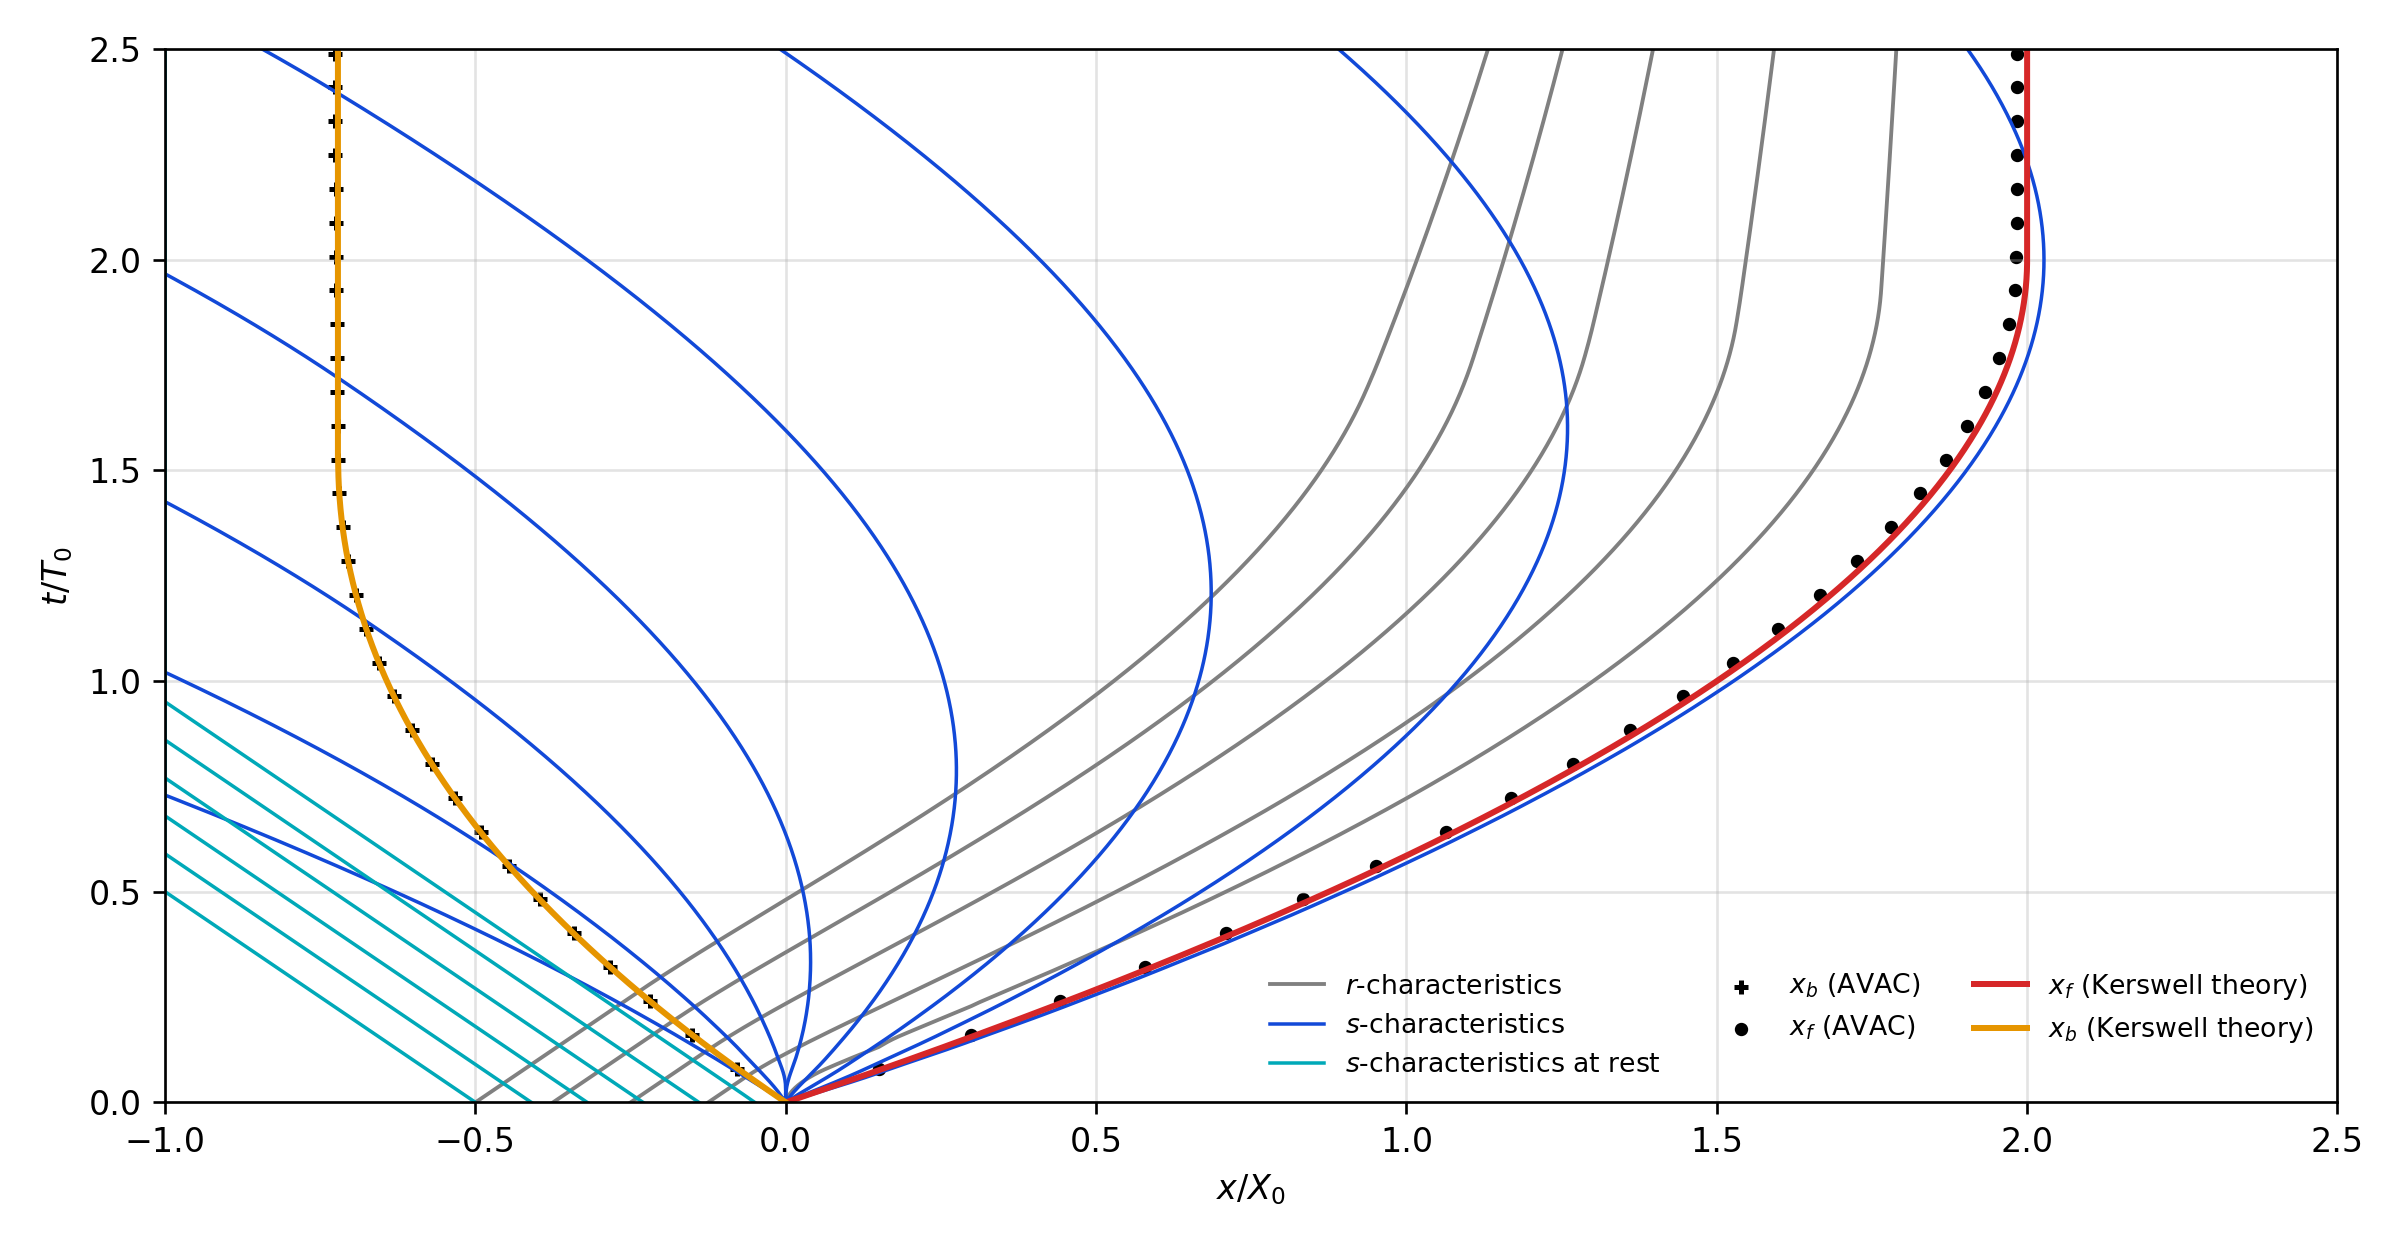

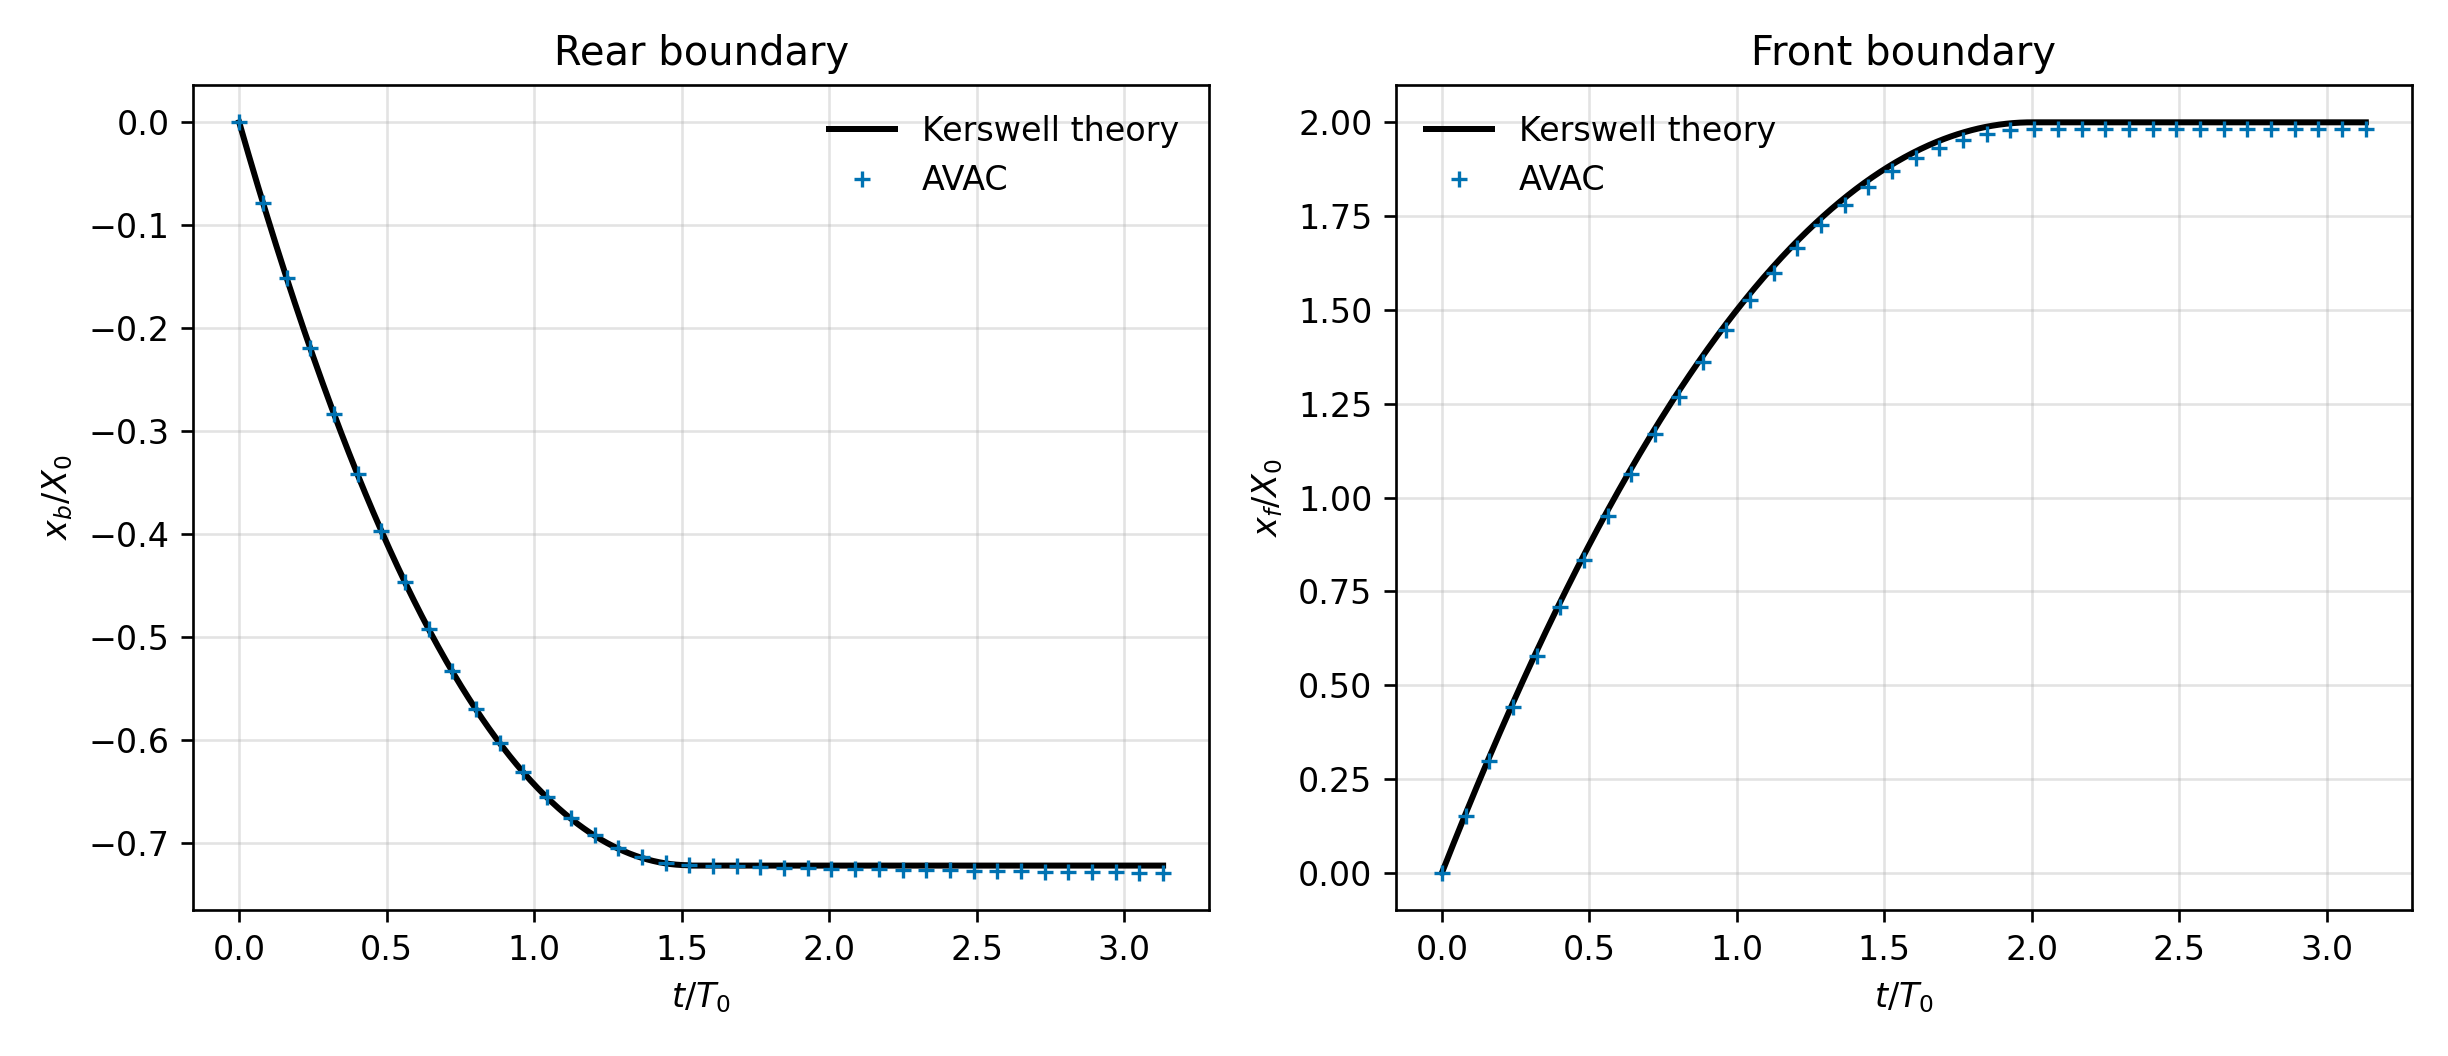

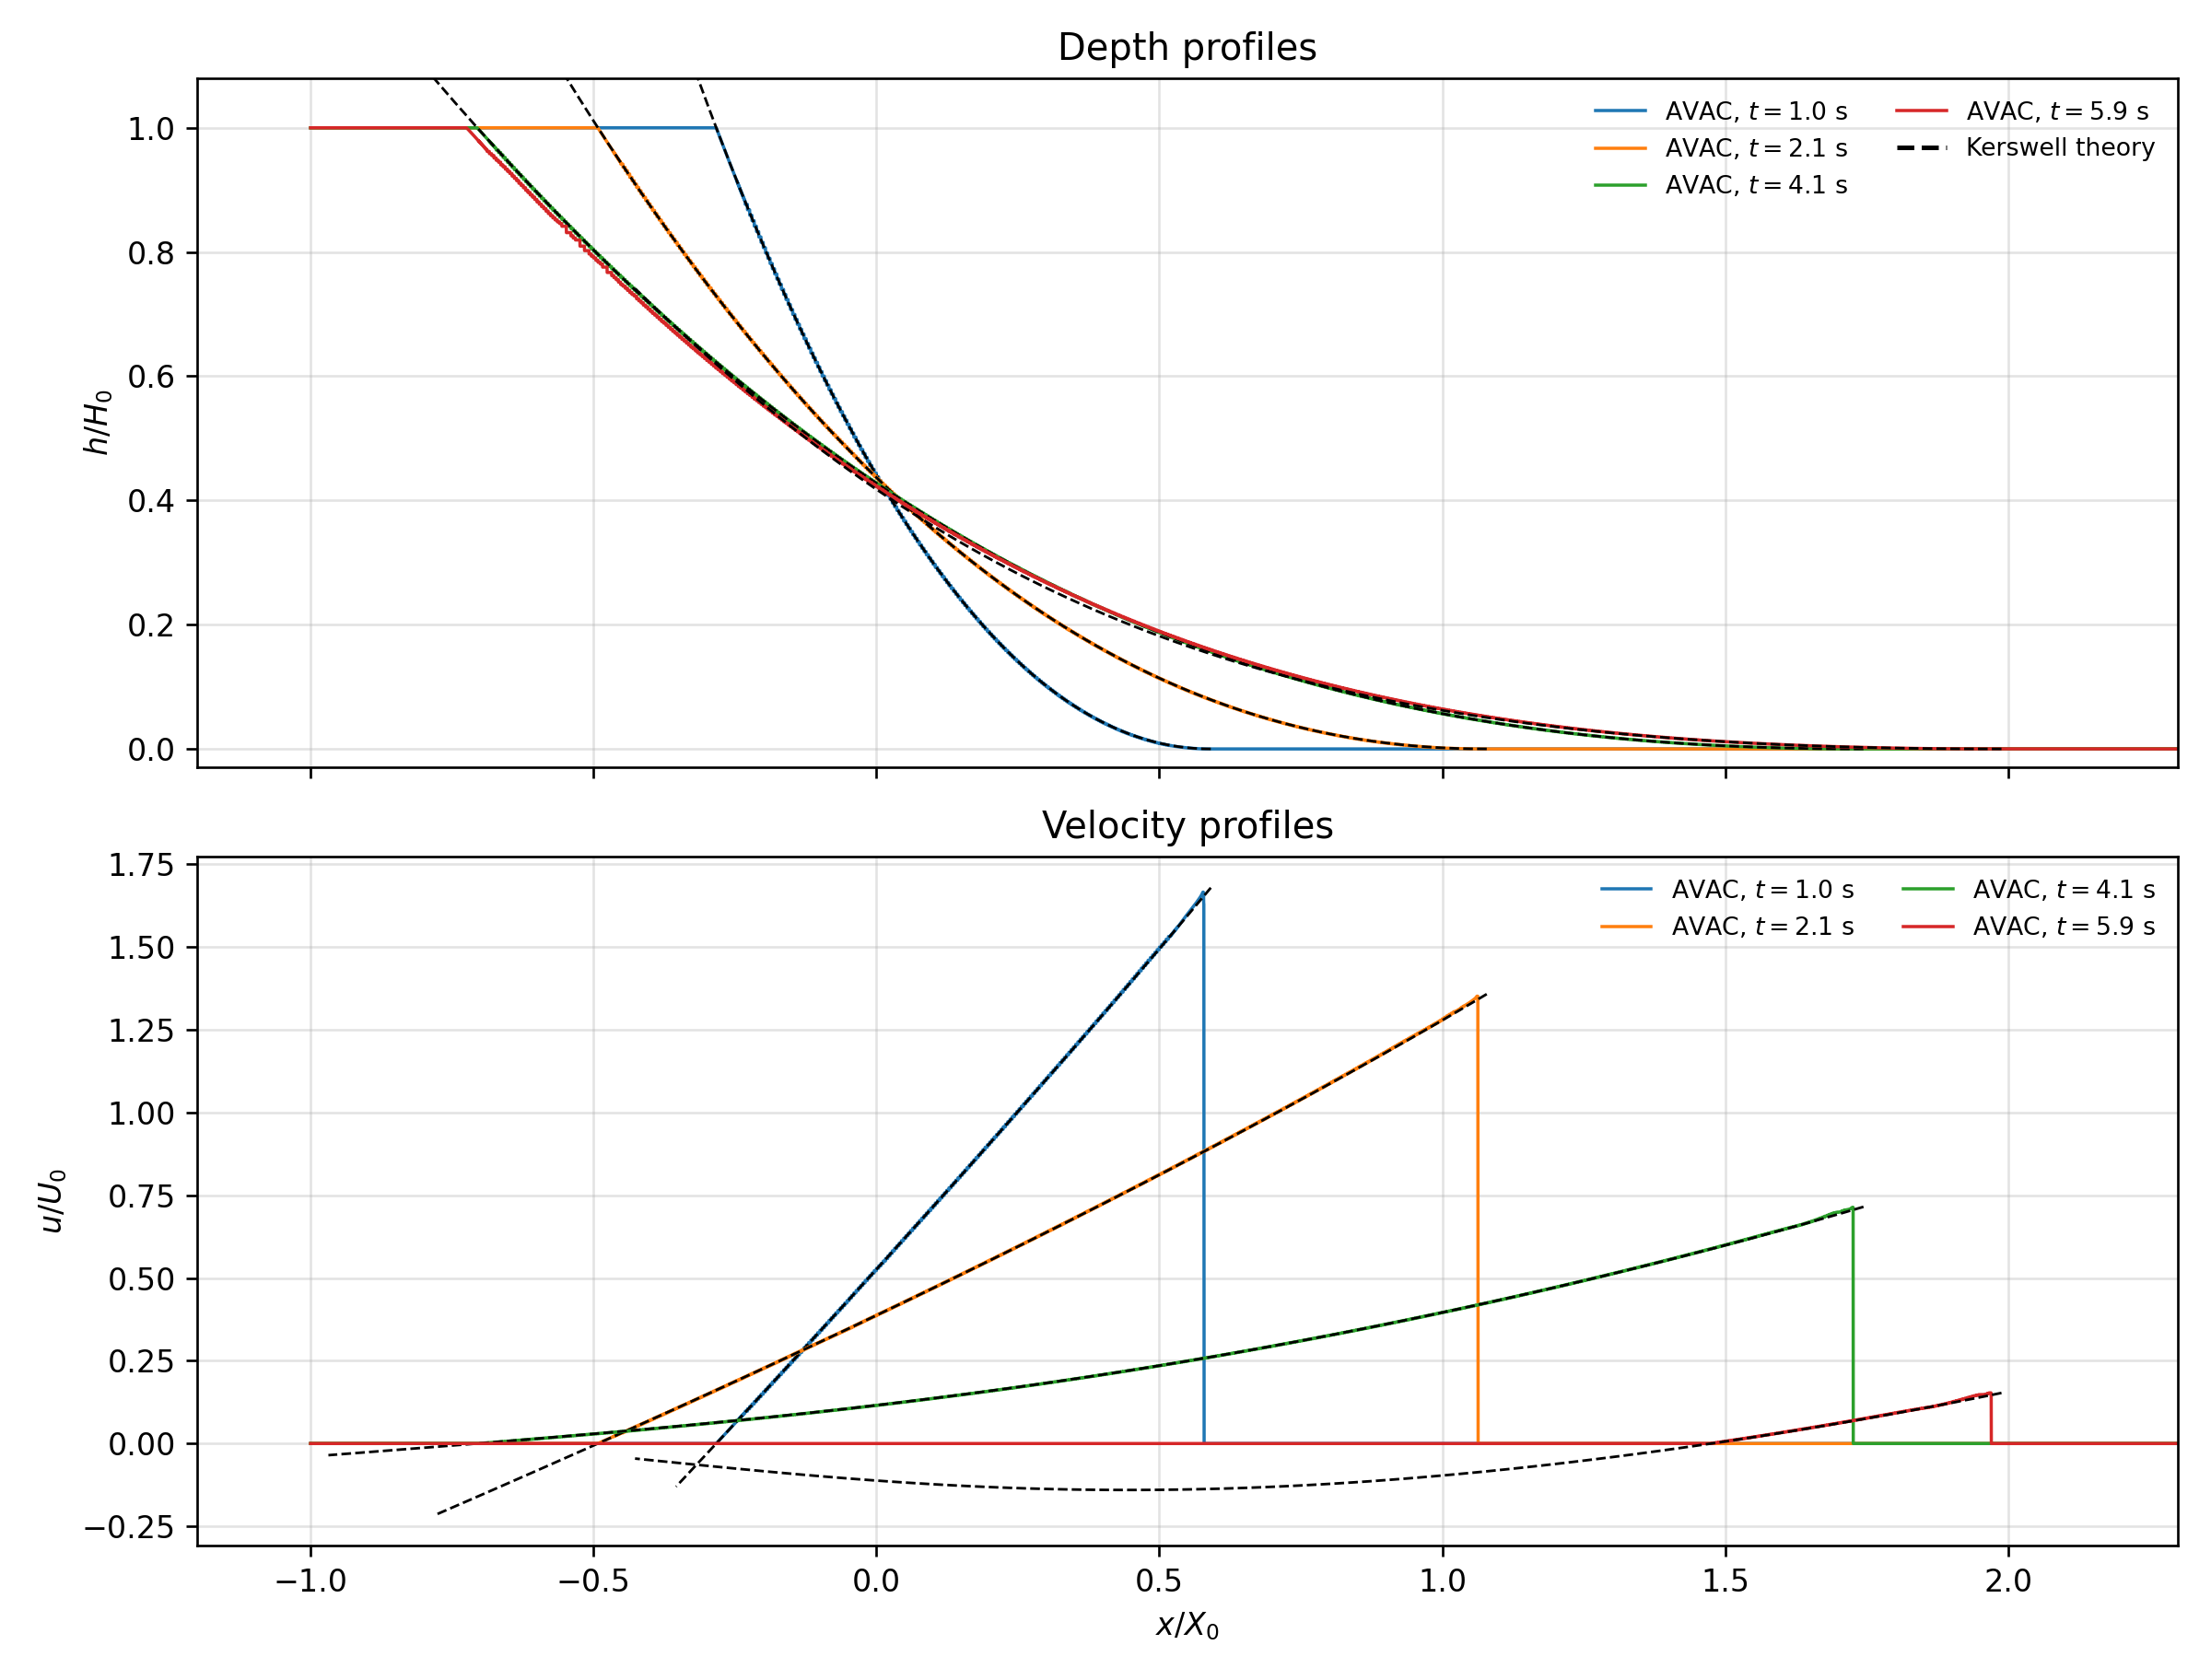

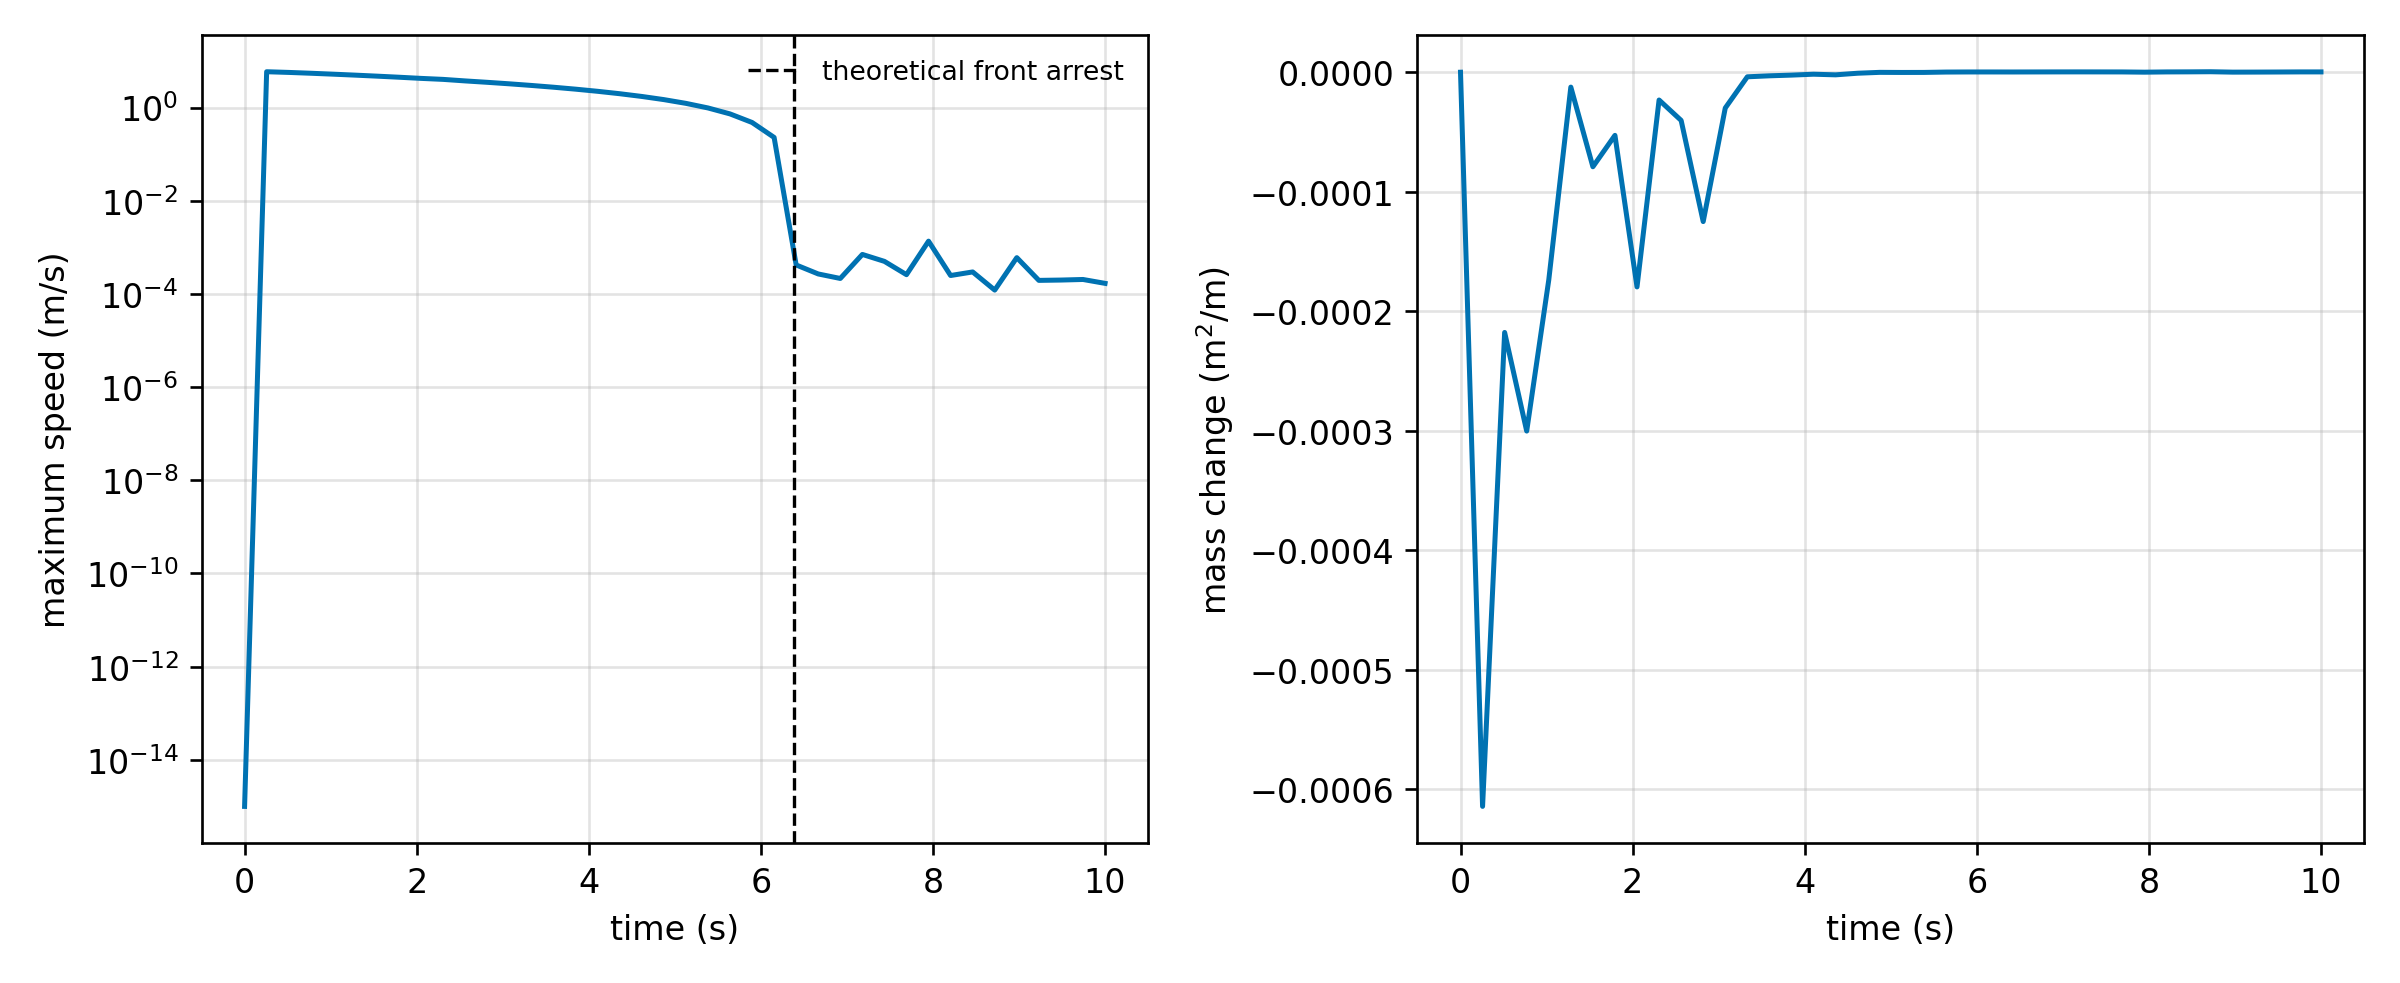

In [5]:
case.show(f'{RUN_NAME}/figures/figure_8_7_avac_vs_theory.png', f'{RUN_NAME}/figures/figure_8_10_avac_vs_theory.png', f'{RUN_NAME}/figures/profiles_avac_vs_theory.png', f'{RUN_NAME}/figures/avac_arrest_and_mass.png')
